In [1]:
from auxilary.bad_sorts import *
import matplotlib.pyplot as plt
import timeit
import gc

In [4]:
list_length = 2000
max_value = 10000
runs_per_swap = 5

swaps_list = [0, 10, 50, 100, 250, 500, 1000, 1500, 2000, 3301]

bubble_times = []
insertion_times = []
selection_times = []

for swaps in swaps_list:
    bubble_runs = []
    insertion_runs = []
    selection_runs = []

    for _ in range(runs_per_swap):
        L = create_near_sorted_list(list_length, max_value, swaps)

        L1 = L.copy()
        L2 = L.copy()
        L3 = L.copy()

        start = timeit.default_timer()
        bubble_sort(L1)
        bubble_runs.append(timeit.default_timer() - start)

        start = timeit.default_timer()
        insertion_sort(L2)
        insertion_runs.append(timeit.default_timer() - start)

        start = timeit.default_timer()
        selection_sort(L3)
        selection_runs.append(timeit.default_timer() - start)

    bubble_times.append(min(bubble_runs))
    insertion_times.append(min(insertion_runs))
    selection_times.append(min(selection_runs))

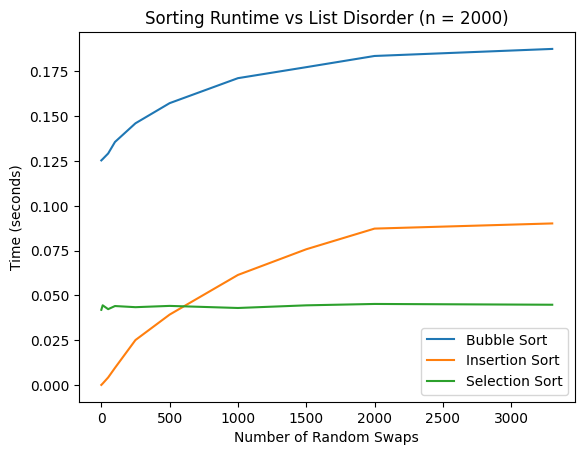

In [5]:
plt.figure()
plt.plot(swaps_list, bubble_times, label="Bubble Sort")
plt.plot(swaps_list, insertion_times, label="Insertion Sort")
plt.plot(swaps_list, selection_times, label="Selection Sort")

plt.xlabel("Number of Random Swaps")
plt.ylabel("Time (seconds)")
plt.title("Sorting Runtime vs List Disorder (n = 2000)")
plt.legend()
plt.show()

**Explicit Outline**

These experiments were performed on the original "bad" sorting algorithms (not their improved counterparts). 

I fixed the list length at n = 2000 and the maximum value at 10000.
I generated near sorted lists using the function provided (create_near_sorted_list)
The number of random swaps was varied from 0 up to 2000 in the intervals (0, 10, 50, 100, 250, 500, 1000, 1500, 2000)
For each swap count, I ran 5 trials and recorded the minimum execution time for more consistent results.

**Conclusion**

The experiment shows interesting aspects of each sorting algorithm.

Insertion Sort seems very sensitive to the amount of disorder in the list. When the number of swaps is small (Seeming to be around 600), Insertion Sort is the best performing algorithm of the three, as it requires minimal shifting. However, as the number of swaps increases, its runtime grows rapidly and it performs worse than selection sort, but not as bad as bubble sort.

Bubble Sort also benefits from near-sorted input, but to a lesser extent, as it still requires repeated passes through the list. Overall it is the worst-performing algorithm in all cases.

Selection Sort has very stable performance regardless of disorder since it always performs the same number of comparisons and swaps, even when the list is nearly sorted.

Overall, I think this experiment highlights how algorithms like Insertion Sort can significantly outperform others when the input is nearly sorted, despite having the same worst-case time complexity.